In [1]:
from types import SimpleNamespace
from model.model import GPT
import torch
import torch.nn as nn

# loading the gpt model and customizing it parameters
gpt1 = GPT(SimpleNamespace(vocab_size=100,n_layers=2,dropout=0.1,n_embd=200, n_head=8, attn_pdrop=0.1, resid_pdrop=0.1, block_size=100))

In [2]:
gpt1.get_num_params()

'Total Parameters: 1,025,600'

In [9]:
# toy dataset n-->n+1

class NumberDataset(torch.utils.data.Dataset):
    def __init__(self):
        self.data  = list(range(100))

    def __len__(self):
        return len(self.data)-1

    def __getitem__(self, idx):
        return torch.tensor([self.data[idx]], dtype=torch.long), torch.tensor([self.data[idx+1]], dtype=torch.long)
dataset = NumberDataset()

In [10]:
from model.trainer import Trainer

# loading the trainer and giving it the parameters config , model , dataset

config = SimpleNamespace(epochs=10,batch_size=4,lr=1e-3,shuffle=True)
trainer = Trainer(config,gpt1,dataset)
trainer.train(use_tqdm=True)

Epoch 10/10: 100%|██████████| 25/25 [00:00<00:00, 49.94it/s, loss=0.000101]


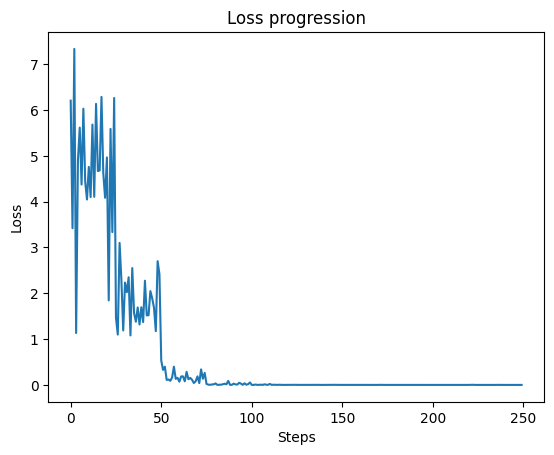

In [11]:
trainer.plot_loss()